         Model       MSE       MAE        R²
0       Linear  0.555892  0.533200  0.575788
1        Lasso  0.547933  0.535523  0.581861
2        Ridge  0.555888  0.533199  0.575791
3  Elastic Net  0.551539  0.533503  0.579109


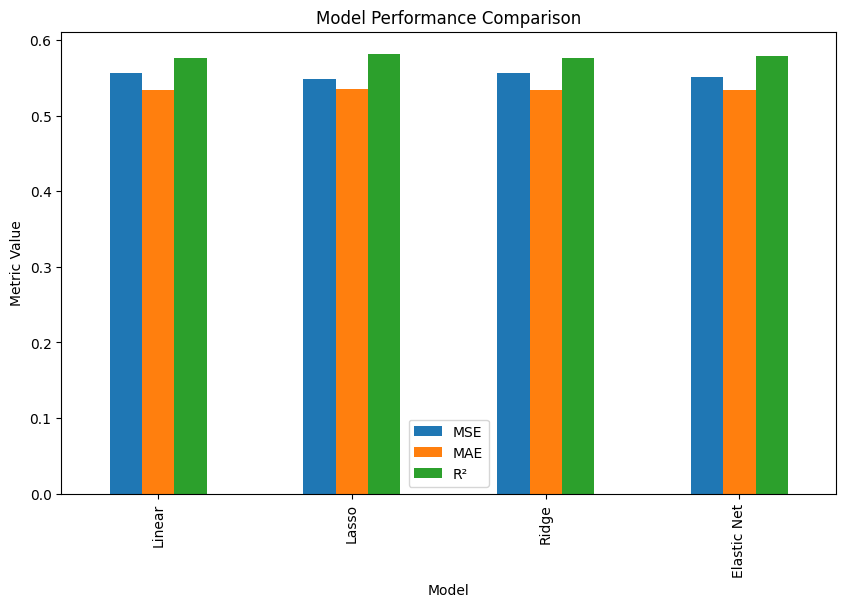

      Feature    Linear     Lasso     Ridge  Elastic Net
0      MedInc  0.852382  0.795304  0.852375     0.835960
1    HouseAge  0.122382  0.127002  0.122390     0.132191
2    AveRooms -0.305116 -0.159392 -0.305091    -0.257625
3   AveBedrms  0.371132  0.216282  0.371101     0.313904
4  Population -0.002298 -0.000000 -0.002296     0.000000
5    AveOccup -0.036624 -0.028295 -0.036624    -0.036107
6    Latitude -0.896635 -0.792230 -0.896560    -0.789696
7   Longitude -0.868927 -0.756737 -0.868851    -0.759600


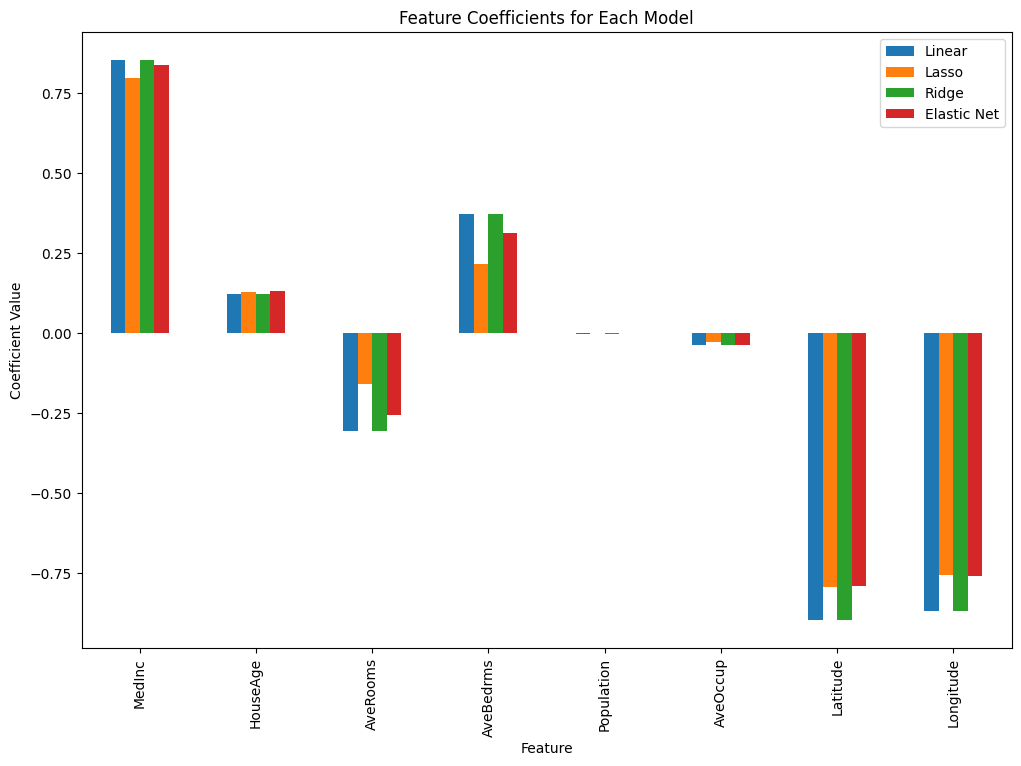

In [1]:
# Import necessary libraries
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the California Housing dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Preprocess the data
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Fit Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# Fit Lasso Regression model with hyperparameter tuning
lasso_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
lasso_model = GridSearchCV(Lasso(), lasso_params, cv=5, scoring='r2')
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.best_estimator_.predict(X_test)

# Fit Ridge Regression model with hyperparameter tuning
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_model = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.best_estimator_.predict(X_test)

# Fit Elastic Net Regression model with hyperparameter tuning
elastic_params = {'alpha': [0.01, 0.1, 1, 10, 100], 'l1_ratio': [0.1, 0.5, 0.9]}
elastic_model = GridSearchCV(ElasticNet(), elastic_params, cv=5, scoring='r2')
elastic_model.fit(X_train, y_train)
y_pred_elastic = elastic_model.best_estimator_.predict(X_test)

# Evaluate models
results = pd.DataFrame({
    'Model': ['Linear', 'Lasso', 'Ridge', 'Elastic Net'],
    'MSE': [mean_squared_error(y_test, y_pred_linear),
            mean_squared_error(y_test, y_pred_lasso),
            mean_squared_error(y_test, y_pred_ridge),
            mean_squared_error(y_test, y_pred_elastic)],
    'MAE': [mean_absolute_error(y_test, y_pred_linear),
            mean_absolute_error(y_test, y_pred_lasso),
            mean_absolute_error(y_test, y_pred_ridge),
            mean_absolute_error(y_test, y_pred_elastic)],
    'R²': [r2_score(y_test, y_pred_linear),
           r2_score(y_test, y_pred_lasso),
           r2_score(y_test, y_pred_ridge),
           r2_score(y_test, y_pred_elastic)]
})
print(results)

# Plot model performance
results.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Metric Value')
plt.show()

# Display coefficients for each model
coefficients = pd.DataFrame({
    'Feature': data.feature_names,
    'Linear': linear_model.coef_,
    'Lasso': lasso_model.best_estimator_.coef_,
    'Ridge': ridge_model.best_estimator_.coef_,
    'Elastic Net': elastic_model.best_estimator_.coef_
})
print(coefficients)

# Plot coefficients
coefficients.set_index('Feature').plot(kind='bar', figsize=(12, 8))
plt.title('Feature Coefficients for Each Model')
plt.ylabel('Coefficient Value')
plt.show()
